# Data Cleaning and Preprocessing

This notebook prepares the combined Airbnb dataset for exploratory analysis and modelling. The process includes correcting data types, assessing and treating missing values, checking duplicate records, identifying invalid values, evaluating outliers and creating relevant engineered features.

The original data is preserved, and all transformations are applied to a separate working copy. The final cleaned dataset is exported to the `data/processed` directory.

In [1]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from openpyxl import Workbook 
from openpyxl.styles import Alignment, Border, Font, PatternFill, Side 
from openpyxl.utils import get_column_letter

warnings.filterwarnings("ignore")

In [2]:
# Project Paths

PROJECT_ROOT = Path.cwd().parent

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"

FIGURES_DIR = PROJECT_ROOT / "figures"
TABLES_DIR = PROJECT_ROOT / "tables"

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print(PROJECT_ROOT)
print(RAW_DATA_DIR)
print(PROCESSED_DATA_DIR)
print(FIGURES_DIR)
print(TABLES_DIR)

c:\Users\Probook\NCIRL 2025-2026\DA for Business\CA_DA for Business
c:\Users\Probook\NCIRL 2025-2026\DA for Business\CA_DA for Business\data\raw
c:\Users\Probook\NCIRL 2025-2026\DA for Business\CA_DA for Business\data\processed
c:\Users\Probook\NCIRL 2025-2026\DA for Business\CA_DA for Business\figures
c:\Users\Probook\NCIRL 2025-2026\DA for Business\CA_DA for Business\tables


In [3]:
# Visualisation Settings

plt.rcdefaults()

plt.rcParams.update({

    "figure.figsize": (10, 6),
    "figure.dpi": 120,
    "savefig.dpi": 300,

    "font.family": "DejaVu Sans",
    "font.size": 11,

    "axes.titlesize": 14,
    "axes.titleweight": "bold",

    "axes.labelsize": 12,
    "axes.labelweight": "bold",

    "xtick.labelsize": 10,
    "ytick.labelsize": 10,

    "axes.spines.top": False,
    "axes.spines.right": False,

    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.linewidth": 0.6,
    "grid.alpha": 0.35,

    "legend.frameon": False
})

In [4]:
# Project Colour Palette

PROJECT_COLOURS = {

    "primary": "#1F77B4",
    "secondary": "#FF7F0E",
    "accent": "#2CA02C",
    "warning": "#D62728",
    "neutral": "#7F7F7F",
    "light": "#AEC7E8"

}

In [5]:
# Figure Export Function

def save_figure(fig, number, filename, title):
    """
    Add a numbered caption and save a matplotlib figure.

    Parameters
    ----------
    fig : matplotlib.figure.Figure
        Figure to save.
    number : int
        Figure number used in the caption.
    filename : str
        Output filename, including the .png extension.
    title : str
        Descriptive figure caption.
    """

    caption = f"Figure {number}. {title}"

    fig.text(
        0.5,
        0.015,
        caption,
        ha="center",
        fontsize=11,
        style="italic"
    )

    fig.tight_layout(rect=[0, 0.05, 1, 1])

    output_path = FIGURES_DIR / filename

    fig.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    print(f"Figure saved to: {output_path}")

In [6]:
# Table Export Function

def save_table_excel(
    dataframe,
    filename,
    caption,
    sheet_name="Table",
    decimal_places=2,
    percentage_columns=None,
    currency_columns=None,
    index=False
):
    """
    Save a pandas DataFrame as a formatted Excel workbook.

    Parameters
    ----------
    dataframe : pandas.DataFrame
        DataFrame to export.

    filename : str
        Output filename, for example:
        'table_01_dataset_overview.xlsx'

    caption : str
        Caption placed above the table.

    sheet_name : str, default='Table'
        Excel worksheet name.

    decimal_places : int, default=2
        Number of decimal places for floating-point columns.

    percentage_columns : list, optional
        Columns that already contain percentage-point values,
        for example 35.5 for 35.5%.

    currency_columns : list, optional
        Columns to display using currency formatting.

    index : bool, default=False
        Whether to include the DataFrame index.
    """

    percentage_columns = percentage_columns or []
    currency_columns = currency_columns or []

    table_df = dataframe.copy()

    if index:
        table_df = table_df.reset_index()

    # Replace missing values with blank cells
    table_df = table_df.astype(object).where(
        pd.notna(table_df),
        None
    )

    workbook = Workbook()
    worksheet = workbook.active
    worksheet.title = sheet_name[:31]

    number_of_rows = len(table_df)
    number_of_columns = len(table_df.columns)

    first_column = 1
    last_column = number_of_columns

    header_row = 3
    data_start_row = header_row + 1
    data_end_row = data_start_row + number_of_rows - 1

    # Project colours
    primary_colour = PROJECT_COLOURS["primary"].replace("#", "")
    light_colour = PROJECT_COLOURS["light"].replace("#", "")

    white_colour = "FFFFFF"
    border_colour = "D9D9D9"
    alternate_row_colour = "F4F7FA"

    thin_border = Side(
        style="thin",
        color=border_colour
    )

    cell_border = Border(
        left=thin_border,
        right=thin_border,
        top=thin_border,
        bottom=thin_border
    )

    # Caption
    
    worksheet.merge_cells(
        start_row=1,
        start_column=first_column,
        end_row=1,
        end_column=last_column
    )

    caption_cell = worksheet.cell(
        row=1,
        column=1,
        value=caption
    )

    caption_cell.font = Font(
        name="Calibri",
        size=13,
        bold=True,
        italic=True
    )

    caption_cell.alignment = Alignment(
        horizontal="center",
        vertical="center"
    )

    worksheet.row_dimensions[1].height = 24

        # Column headers
    
    for column_number, column_name in enumerate(
        table_df.columns,
        start=1
    ):
        cell = worksheet.cell(
            row=header_row,
            column=column_number,
            value=str(column_name)
        )

        cell.fill = PatternFill(
            fill_type="solid",
            fgColor=primary_colour
        )

        cell.font = Font(
            name="Calibri",
            size=11,
            bold=True,
            color=white_colour
        )

        cell.alignment = Alignment(
            horizontal="center",
            vertical="center",
            wrap_text=True
        )

        cell.border = cell_border

    worksheet.row_dimensions[header_row].height = 30

        # Table data
    
    for row_offset, row_values in enumerate(
        table_df.itertuples(index=False, name=None),
        start=data_start_row
    ):
        for column_number, value in enumerate(
            row_values,
            start=1
        ):
            cell = worksheet.cell(
                row=row_offset,
                column=column_number,
                value=value
            )

            cell.font = Font(
                name="Calibri",
                size=10
            )

            cell.border = cell_border
            cell.alignment = Alignment(
                vertical="center",
                wrap_text=True
            )

            # Alternate row shading
            if (row_offset - data_start_row) % 2 == 1:
                cell.fill = PatternFill(
                    fill_type="solid",
                    fgColor=alternate_row_colour
                )

        worksheet.row_dimensions[row_offset].height = 21

        # Alignment and number formatting
    
    original_dataframe = dataframe.reset_index() if index else dataframe

    for column_number, column_name in enumerate(
        table_df.columns,
        start=1
    ):
        excel_column = get_column_letter(column_number)

        # First column left-aligned, remaining columns centred
        alignment = "left" if column_number == 1 else "center"

        for row_number in range(data_start_row, data_end_row + 1):
            worksheet.cell(
                row=row_number,
                column=column_number
            ).alignment = Alignment(
                horizontal=alignment,
                vertical="center",
                wrap_text=True
            )

        if column_name not in original_dataframe.columns:
            continue

        original_column = original_dataframe[column_name]

        # Percentage values such as 35.50 are shown as 35.50%
        if column_name in percentage_columns:
            number_format = (
                "0." + ("0" * decimal_places) + "%"
            )

            # Excel expects 0.355 for 35.5%, so divide by 100
            for row_number in range(data_start_row, data_end_row + 1):
                cell = worksheet.cell(
                    row=row_number,
                    column=column_number
                )

                if isinstance(cell.value, (int, float)):
                    cell.value = cell.value / 100
                    cell.number_format = number_format

        elif column_name in currency_columns:
            number_format = (
                '$#,##0'
                if decimal_places == 0
                else '$#,##0.' + ("0" * decimal_places)
            )

            for row_number in range(data_start_row, data_end_row + 1):
                worksheet.cell(
                    row=row_number,
                    column=column_number
                ).number_format = number_format

        elif pd.api.types.is_integer_dtype(original_column):
            for row_number in range(data_start_row, data_end_row + 1):
                worksheet.cell(
                    row=row_number,
                    column=column_number
                ).number_format = "#,##0"

        elif pd.api.types.is_float_dtype(original_column):
            number_format = (
                "#,##0"
                if decimal_places == 0
                else "#,##0." + ("0" * decimal_places)
            )

            for row_number in range(data_start_row, data_end_row + 1):
                worksheet.cell(
                    row=row_number,
                    column=column_number
                ).number_format = number_format

        # Automatic column widths
    
    for column_number, column_name in enumerate(
        table_df.columns,
        start=1
    ):
        excel_column = get_column_letter(column_number)

        content_lengths = [
            len(str(column_name))
        ]

        for value in table_df[column_name]:
            if value is not None:
                content_lengths.append(len(str(value)))

        maximum_length = max(content_lengths)

        if column_number == 1:
            column_width = min(
                max(maximum_length + 3, 20),
                42
            )
        else:
            column_width = min(
                max(maximum_length + 3, 12),
                22
            )

        worksheet.column_dimensions[
            excel_column
        ].width = column_width

        # Worksheet settings
   
    worksheet.freeze_panes = f"A{data_start_row}"

    worksheet.sheet_view.showGridLines = False

    worksheet.auto_filter.ref = (
        f"A{header_row}:"
        f"{get_column_letter(last_column)}{data_end_row}"
    )

    worksheet.page_setup.orientation = (
        "landscape"
        if number_of_columns > 5
        else "portrait"
    )

    worksheet.page_setup.fitToWidth = 1
    worksheet.page_setup.fitToHeight = 0
    worksheet.sheet_properties.pageSetUpPr.fitToPage = True

    worksheet.print_title_rows = f"1:{header_row}"

    worksheet.print_area = (
        f"A1:"
        f"{get_column_letter(last_column)}{data_end_row}"
    )

        # Save workbook
    
    output_path = TABLES_DIR / filename

    workbook.save(output_path)

    print(f"Table saved to: {output_path}")

In [7]:
airbnb_raw = pd.read_csv(
    PROCESSED_DATA_DIR / "airbnb_combined_raw.csv",
    low_memory=False
)

print(f"Dataset loaded successfully.")
print(f"Shape: {airbnb_raw.shape}")

Dataset loaded successfully.
Shape: (145825, 57)


In [8]:
airbnb_clean = airbnb_raw.copy(deep=True)

In [9]:
# Inspect instant_bookable

display(
    airbnb_clean["instant_bookable"]
    .value_counts(dropna=False)
)

instant_bookable
NaN    63514
0.0    48495
1.0    33816
Name: count, dtype: int64

In [10]:
# Inspect Instantbook Enabled
display(
    airbnb_clean["Instantbook Enabled"]
    .value_counts(dropna=False)
)

Instantbook Enabled
False    112009
True      33816
Name: count, dtype: int64

In [11]:
comparison = pd.crosstab(
    airbnb_clean["instant_bookable"],
    airbnb_clean["Instantbook Enabled"],
    dropna=False
)

display(comparison)

save_table_excel(
    dataframe=comparison,
    filename="table_04_instant_booking_comparison.xlsx",
    caption="Table 4. Comparison of Instant Booking Variables",
    sheet_name="Instant Booking",
    decimal_places=0
)

Instantbook Enabled,False,True
instant_bookable,,
0.0,48495,0
1.0,0,33816
NaN,63514,0


Table saved to: c:\Users\Probook\NCIRL 2025-2026\DA for Business\CA_DA for Business\tables\table_04_instant_booking_comparison.xlsx


The variables **instant_bookable** and **Instantbook Enabled** were compared to determine whether they represented the same information. A cross-tabulation confirmed that all values were consistent between the two variables, with `1.0` corresponding to `True`, `0.0` corresponding to `False`, and all missing values in `instant_bookable` also represented as `False` in `Instantbook Enabled`.

As `Instantbook Enabled` contained no missing values and fully represented the same information, the `instant_bookable` variable can be removed from the dataset.

In [12]:
# Inspect Amenities

airbnb_clean["Amenities"].isna().sum()

np.int64(0)

In [13]:
airbnb_clean["Amenities"].sample(10, random_state=42)

13770     ['Free parking on premises', 'Wifi', 'Cable TV...
62403     ['Wifi', 'Hair dryer', 'Shampoo', 'Iron', 'Han...
78984     ['Free parking on premises', 'Kitchen', 'Wifi'...
23617     ['Breakfast', 'Kitchen', 'Wifi', 'Cable TV', '...
125219    ['Free parking on premises', 'Wifi', 'Kitchen'...
52111     ['Free parking on premises', 'Wifi', 'Kitchen'...
91245     ['Wifi', 'Kitchen', 'Indoor fireplace', 'Free ...
115677    ['Kitchen', 'Wifi', 'TV', 'Smoke alarm', 'Carb...
109060    ['Indoor fireplace', 'Kitchen', 'Wifi', 'Iron'...
53230     ['Elevator', 'Free parking on premises', 'Wifi...
Name: Amenities, dtype: str

##### will leave as it is, may be used for feature engineering in modelling part, if not we will exclude it from predictive modelling.

In [14]:
columns_to_review = [
    "Listing URL",
    "picture_url",
    "Airbnb Property ID",
    "Airbnb Host ID",
    "Currency Native",
    "Zipcode",
    "Exact Location",
    "State"
]

airbnb_clean[columns_to_review].head()

,Listing URL,picture_url,Airbnb Property ID,Airbnb Host ID,Currency Native,Zipcode,Exact Location,State
0,http://airbnb.com/rooms/745527124427190386,https://a0.muscache.com/im/pictures/prohost-ap...,745527124427190386,25117311,AED,25314,f,NaN
1,http://airbnb.com/rooms/48555713,https://a0.muscache.com/im/pictures/prohost-ap...,48555713,188310727,AED,25314,t,NaN
2,http://airbnb.com/rooms/658364273139680995,https://a0.muscache.com/im/pictures/prohost-ap...,658364273139680995,418671655,AED,25314,f,NaN
3,http://airbnb.com/rooms/44691977,https://a0.muscache.com/im/pictures/86e36401-3...,44691977,74933177,AED,25314,t,NaN
4,http://airbnb.com/rooms/730932111426284794,https://a0.muscache.com/im/pictures/miso/Hosti...,730932111426284794,167648591,AED,25314,t,NaN


In [15]:
airbnb_clean[columns_to_review].info()

<class 'pandas.DataFrame'>
RangeIndex: 145825 entries, 0 to 145824
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype
---  ------              --------------   -----
 0   Listing URL         145825 non-null  str  
 1   picture_url         145825 non-null  str  
 2   Airbnb Property ID  145825 non-null  int64
 3   Airbnb Host ID      145825 non-null  int64
 4   Currency Native     145825 non-null  str  
 5   Zipcode             129983 non-null  str  
 6   Exact Location      145825 non-null  str  
 7   State               130623 non-null  str  
dtypes: int64(2), str(6)
memory usage: 8.9 MB


In [16]:
airbnb_clean["License"].value_counts(dropna=False).head(20)

License
NaN                                                                     117212
Exempt                                                                    1285
Exempt - This listing is a transient occupancy residential structure       418
Exempt - This listing is a hotel or motel                                  320
Exempt - This listing is a bed and breakfast                               224
License not needed per OSTR                                                159
City registration pending                                                  118
825766                                                                      77
pending                                                                     60
787243                                                                      58
100554747400003                                                             51
City Registration Pending                                                   44
Approved by government                      

In [17]:
# Removing columns

columns_to_remove = [
    "instant_bookable",
    "Last Host Count Updated Date",
    "Neighbourhood",
    "Metropolitan Statistical Area",
    "License",
    "Listing URL",
    "picture_url",
    "Airbnb Property ID",
    "Airbnb Host ID",
    "Currency Native",
    "Cleaning Fee (Native)",
    "Extra People Fee(Native)",
    "Average Daily Rate (Native)",
    "Annual Revenue LTM (Native)"
]

airbnb_clean.drop(columns=columns_to_remove, inplace=True)

print(f"Updated dataset shape: {airbnb_clean.shape}")

display(airbnb_clean.head())

Updated dataset shape: (145825, 43)


,Listing Title,Property Type,Listing Type,Created Date,Last Scraped Date,Country,City,Zipcode,Number of Reviews,Bedrooms,...,Instantbook Enabled,Count Available Days LTM,Count Blocked Days LTM,Count Reservation Days LTM,Occupancy Rate LTM,Number of Bookings LTM,Number of Bookings LTM - Number of observed month,Average Daily Rate (USD),Annual Revenue LTM (USD),State
0,Spacious & Private Townhome | 5 mins drive to ...,Entire rental unit,entire_home,2023-07-31,2024-01-10,AE,Dubai,25314,1,3,...,False,28,337,18,77,9,6,145,3126,NaN
1,Spacious and Ornate 2BR Apartment in Dubai South,Entire rental unit,entire_home,2023-07-31,2024-01-10,AE,Dubai,25314,24,2,...,False,333,32,217,78,24,21,79,21815,NaN
2,Exceptional 2BR near Expo City Dubai!,Entire rental unit,entire_home,2023-07-31,2024-01-10,AE,Dubai,25314,13,2,...,False,219,146,176,96,14,11,70,14717,NaN
3,Stylish Apartment Surrounded by Lush Green Parks!,Entire rental unit,entire_home,2023-07-31,2024-01-10,AE,Dubai,25314,12,2,...,True,253,112,182,86,9,6,192,41775,NaN
4,OFFER! 50% OFF! I am very cool and sleep 6!,Entire condo,entire_home,2023-07-31,2024-01-03,AE,Dubai,25314,10,2,...,False,137,228,50,44,6,3,74,4461,NaN


In [18]:
# Table 5. Variables Removed During Data Cleaning 

removed_columns = pd.DataFrame({
    "Variable": [
        "instant_bookable",
        "Last Host Count Updated Date",
        "Neighbourhood",
        "Metropolitan Statistical Area",
        "License",
        "Listing URL",
        "picture_url",
        "Airbnb Property ID",
        "Airbnb Host ID",
        "Currency Native",
        "Cleaning Fee (Native)",
        "Extra People Fee(Native)",
        "Average Daily Rate (Native)",
        "Annual Revenue LTM (Native)"
    ],
    "Reason for Removal": [
        "Duplicated the information contained in 'Instantbook Enabled', which provides the same information without missing values.",
        "99.54% missing values, providing insufficient information for meaningful analysis.",
        "97.61% missing values, providing insufficient information for meaningful analysis.",
        "96.94% missing values, providing insufficient information for meaningful analysis.",
        "Contained over 80% missing values and highly inconsistent registration information, making it unsuitable for analysis without extensive preprocessing.",
        "Administrative URL used only to identify listings and not relevant to the analytical objectives.",
        "Image URL with no analytical value for the study.",
        "Unique identifier with no explanatory value.",
        "Unique identifier with no explanatory value.",
        "Original currency code was redundant because standardized USD monetary variables were retained.",
        "Duplicate monetary measure; USD equivalent retained for consistency.",
        "Duplicate monetary measure; USD equivalent retained for consistency.",
        "Duplicate monetary measure; USD equivalent retained for consistency.",
        "Duplicate monetary measure; USD equivalent retained for consistency."
    ]
})

display(removed_columns)

save_table_excel(
    dataframe=removed_columns,
    filename="table_05_removed_variables.xlsx",
    caption="Table 5. Variables Removed During Data Cleaning",
    sheet_name="Removed Variables",
    decimal_places=0
)

,Variable,Reason for Removal
0,instant_bookable,Duplicated the information contained in 'Insta...
1,Last Host Count Updated Date,"99.54% missing values, providing insufficient ..."
2,Neighbourhood,"97.61% missing values, providing insufficient ..."
3,Metropolitan Statistical Area,"96.94% missing values, providing insufficient ..."
4,License,Contained over 80% missing values and highly i...
5,Listing URL,Administrative URL used only to identify listi...
6,picture_url,Image URL with no analytical value for the study.
7,Airbnb Property ID,Unique identifier with no explanatory value.
8,Airbnb Host ID,Unique identifier with no explanatory value.
9,Currency Native,Original currency code was redundant because s...


Table saved to: c:\Users\Probook\NCIRL 2025-2026\DA for Business\CA_DA for Business\tables\table_05_removed_variables.xlsx


#### Data type conversion

In [19]:
# Inspect Bedrooms
airbnb_clean["Bedrooms"].unique()

<StringArray>
[     '3',      '2',      '1', 'Studio',      '4',      '5',      '9',
      '6',     '12',      '7',      '8',      '0',     '15',     '14',
     '13',     '10',     '16',     '22',     '11',     '24',     '18',
     '21',     '20',     '30',     '36']
Length: 25, dtype: str

In [20]:
# Replace 'Studio' with 0 bedrooms
airbnb_clean["Bedrooms"] = airbnb_clean["Bedrooms"].replace("Studio", "0")

# Convert to integer
airbnb_clean["Bedrooms"] = airbnb_clean["Bedrooms"].astype(int)

airbnb_clean["Bedrooms"].dtype

dtype('int64')

In [21]:
# Convert Date Variables

date_columns = [
    "Created Date",
    "Last Scraped Date"
]

for column in date_columns:
    airbnb_clean[column] = pd.to_datetime(
        airbnb_clean[column],
        errors="coerce"
    )

airbnb_clean[date_columns].dtypes

Created Date         datetime64[us]
Last Scraped Date    datetime64[us]
dtype: object

In [22]:
# Table 6. Data Type Conversions
datatype_changes = pd.DataFrame({
    "Variable": [
        "Bedrooms",
        "Created Date",
        "Last Scraped Date"
    ],
    "Original Data Type": [
        "String",
        "String",
        "String"
    ],
    "New Data Type": [
        "Integer",
        "Datetime",
        "Datetime"
    ],
    "Reason for Conversion": [
        "Replaced 'Studio' with 0 and converted the variable to an integer to enable quantitative analysis.",
        "Converted to datetime format to support temporal analysis and date-based operations.",
        "Converted to datetime format to support temporal analysis and date-based operations."
    ]
})

display(datatype_changes)

save_table_excel(
    dataframe=datatype_changes,
    filename="table_06_data_type_conversions.xlsx",
    caption="Table 6. Data Type Conversions",
    sheet_name="Data Types",
    decimal_places=0
)

,Variable,Original Data Type,New Data Type,Reason for Conversion
0,Bedrooms,String,Integer,Replaced 'Studio' with 0 and converted the var...
1,Created Date,String,Datetime,Converted to datetime format to support tempor...
2,Last Scraped Date,String,Datetime,Converted to datetime format to support tempor...


Table saved to: c:\Users\Probook\NCIRL 2025-2026\DA for Business\CA_DA for Business\tables\table_06_data_type_conversions.xlsx


#### Missing Values Treatment

In [23]:
# Missing Values Summary

missing_summary = (
    airbnb_clean.isna()
    .sum()
    .to_frame("Missing Values")
)

missing_summary["Percentage (%)"] = (
    missing_summary["Missing Values"] /
    len(airbnb_clean) * 100
).round(2)

missing_summary = (
    missing_summary[missing_summary["Missing Values"] > 0]
    .sort_values("Percentage (%)", ascending=False)
)

display(missing_summary)

save_table_excel(
    dataframe=missing_summary,
    filename="table_07_missing_values_summary.xlsx",
    caption="Table 7. Missing Values After Variable Removal",
    sheet_name="Missing Values",
    decimal_places=2
)

,Missing Values,Percentage (%)
Cancellation Policy,63517,43.56
Host Listing Count,59101,40.53
Airbnb Cleanliness Rating,21646,14.84
Overall Rating,20851,14.30
Airbnb Communication Rating,19490,13.37
Airbnb Accuracy Rating,19491,13.37
Airbnb Location Rating,19492,13.37
Airbnb Checkin Rating,19493,13.37
Airbnb Value Rating,19494,13.37
Zipcode,15842,10.86


Table saved to: c:\Users\Probook\NCIRL 2025-2026\DA for Business\CA_DA for Business\tables\table_07_missing_values_summary.xlsx


In [24]:
# Investigate Cancellation Policy
airbnb_clean["Cancellation Policy"].value_counts(dropna=False)

Cancellation Policy
NaN                                 63517
strict_14_with_grace_period         33910
moderate                            21215
flexible                            21134
better_strict_with_grace_period      5389
super_strict_30                       298
super_strict_60                       269
firm_30_strict_with_grace_period       79
luxury_moderate                        11
luxury_super_strict_95                  3
Name: count, dtype: int64

no obvious "Unlnown" category in the dataset. filling with mode would incorrectly classify over 63,000 listings. removing variable = removing meaningful business feature that may influence bookings. the missing values likely indicate unavailable or undisclosed cancellation policies rather than belonging to an existing category. Assigning them to one of the existing policies would introduce bias.

In [25]:
# Investigate Host Listing Count
airbnb_clean["Host Listing Count"].describe()

count    86724.000000
mean        31.282563
std        192.558844
min          0.000000
25%          1.000000
50%          3.000000
75%         10.000000
max       4303.000000
Name: Host Listing Count, dtype: float64

In [26]:
airbnb_clean["Host Listing Count"].value_counts(dropna=False).head(20)

Host Listing Count
NaN     59101
1.0     25891
2.0     11592
3.0      6991
0.0      5252
4.0      4501
5.0      3112
6.0      2510
7.0      1962
9.0      1445
8.0      1417
10.0     1102
11.0     1083
12.0      860
18.0      673
14.0      652
13.0      636
16.0      580
25.0      512
17.0      504
Name: count, dtype: int64

median = 3, mean = 31, max = 4303 - tells that the distribution is extremely right-skewed. mean is heavily influenced by a small number of commercial hosts. median could be the statistical choice to impute, but there are 59,101 missing values. will keep as it is for now.

In [27]:
# Table 8. Missing Value Treatment Decisions

missing_value_treatment = pd.DataFrame({
    "Variable": [
        "Listing Title",
        "Cleaning Fee (USD)",
        "Extra People Fee (USD)",
        "Check-in Time",
        "Checkout Time",
        "Zipcode",
        "State",
        "Overall Rating",
        "Airbnb Accuracy Rating",
        "Airbnb Cleanliness Rating",
        "Airbnb Checkin Rating",
        "Airbnb Communication Rating",
        "Airbnb Location Rating",
        "Airbnb Value Rating",
        "Host Listing Count",
        "Cancellation Policy"
    ],
    "Treatment": [
        "Fill with 'Unknown Listing'",
        "Fill with 0",
        "Fill with 0",
        "Fill with mode",
        "Fill with mode",
        "Retain missing values",
        "Retain missing values",
        "Retain missing values",
        "Retain missing values",
        "Retain missing values",
        "Retain missing values",
        "Retain missing values",
        "Retain missing values",
        "Retain missing values",
        "Retain missing values",
        "Retain missing values"
    ],
    "Justification": [
        "Only six missing records; retaining observations is preferable to deletion.",
        "Missing values likely indicate that no cleaning fee was charged.",
        "Missing values likely indicate that no additional guest fee was charged.",
        "Low proportion of missing values; mode preserves the most common category.",
        "Low proportion of missing values; mode preserves the most common category.",
        "Avoid introducing assumptions; other geographic variables remain available.",
        "Avoid introducing assumptions; other geographic variables remain available.",
        "Missing values likely correspond to listings without guest reviews.",
        "Missing values likely correspond to listings without guest reviews.",
        "Missing values likely correspond to listings without guest reviews.",
        "Missing values likely correspond to listings without guest reviews.",
        "Missing values likely correspond to listings without guest reviews.",
        "Missing values likely correspond to listings without guest reviews.",
        "Missing values likely correspond to listings without guest reviews.",
        "High proportion of missing values and a highly skewed distribution make simple imputation inappropriate.",
        "High proportion of missing values; assigning an existing category would introduce bias."
    ]
})

display(missing_value_treatment)

save_table_excel(
    dataframe=missing_value_treatment,
    filename="table_08_missing_value_treatment.xlsx",
    caption="Table 8. Missing Value Treatment Decisions",
    sheet_name="Missing Values",
    decimal_places=0
)

,Variable,Treatment,Justification
0,Listing Title,Fill with 'Unknown Listing',Only six missing records; retaining observatio...
1,Cleaning Fee (USD),Fill with 0,Missing values likely indicate that no cleanin...
2,Extra People Fee (USD),Fill with 0,Missing values likely indicate that no additio...
3,Check-in Time,Fill with mode,Low proportion of missing values; mode preserv...
4,Checkout Time,Fill with mode,Low proportion of missing values; mode preserv...
5,Zipcode,Retain missing values,Avoid introducing assumptions; other geographi...
6,State,Retain missing values,Avoid introducing assumptions; other geographi...
7,Overall Rating,Retain missing values,Missing values likely correspond to listings w...
8,Airbnb Accuracy Rating,Retain missing values,Missing values likely correspond to listings w...
9,Airbnb Cleanliness Rating,Retain missing values,Missing values likely correspond to listings w...


Table saved to: c:\Users\Probook\NCIRL 2025-2026\DA for Business\CA_DA for Business\tables\table_08_missing_value_treatment.xlsx


In [28]:
# Apply Missing Value Treatment

# Fill missing listing titles
airbnb_clean["Listing Title"] = airbnb_clean["Listing Title"].fillna("Unknown Listing")

# Fill missing monetary values
airbnb_clean["Cleaning Fee (USD)"] = airbnb_clean["Cleaning Fee (USD)"].fillna(0)
airbnb_clean["Extra People Fee (USD)"] = airbnb_clean["Extra People Fee (USD)"].fillna(0)

# Fill missing check-in/check-out times using the mode
airbnb_clean["Check-in Time"] = airbnb_clean["Check-in Time"].fillna(
    airbnb_clean["Check-in Time"].mode()[0]
)

airbnb_clean["Checkout Time"] = airbnb_clean["Checkout Time"].fillna(
    airbnb_clean["Checkout Time"].mode()[0]
)

In [29]:
# Verify remaining missing values

remaining_missing = (
    airbnb_clean.isna()
    .sum()
    .to_frame("Missing Values")
)

remaining_missing["Percentage (%)"] = (
    remaining_missing["Missing Values"] / len(airbnb_clean) * 100
).round(2)

remaining_missing = (
    remaining_missing[remaining_missing["Missing Values"] > 0]
    .sort_values("Percentage (%)", ascending=False)
)

display(remaining_missing)

,Missing Values,Percentage (%)
Cancellation Policy,63517,43.56
Host Listing Count,59101,40.53
Airbnb Cleanliness Rating,21646,14.84
Overall Rating,20851,14.30
Airbnb Checkin Rating,19493,13.37
Airbnb Accuracy Rating,19491,13.37
Airbnb Communication Rating,19490,13.37
Airbnb Value Rating,19494,13.37
Airbnb Location Rating,19492,13.37
Zipcode,15842,10.86


#### Outlier Assessment Treatment

In [30]:
outlier_variables = [
    "Bedrooms",
    "Bathrooms",
    "Max Guests",
    "Cleaning Fee (USD)",
    "Extra People Fee (USD)",
    "Average Daily Rate (USD)",
    "Annual Revenue LTM (USD)",
    "Host Listing Count",
    "Number of Bookings LTM",
    "Occupancy Rate LTM"
]

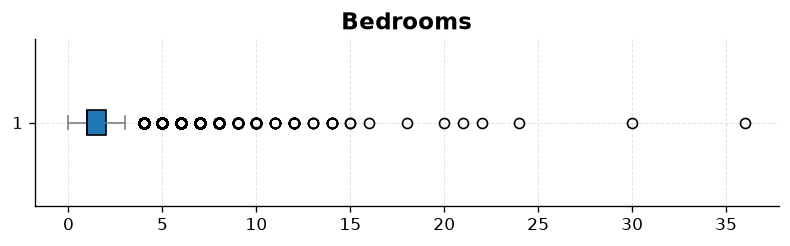

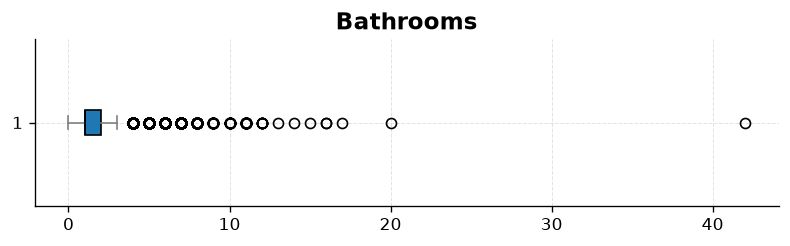

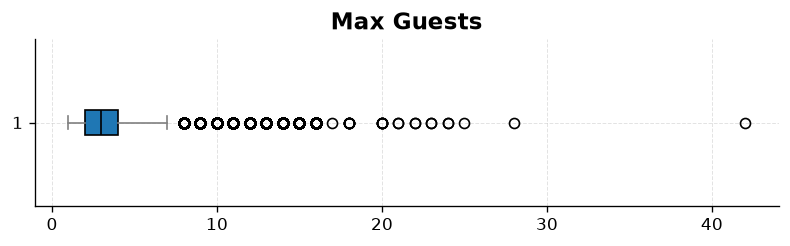

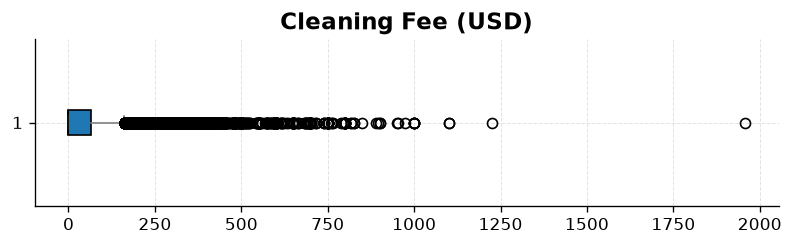

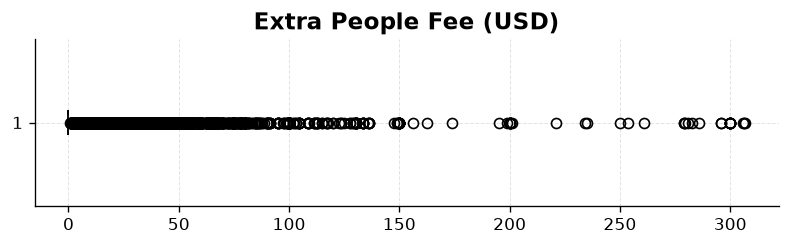

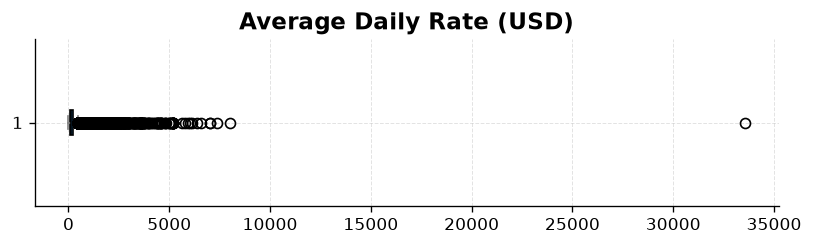

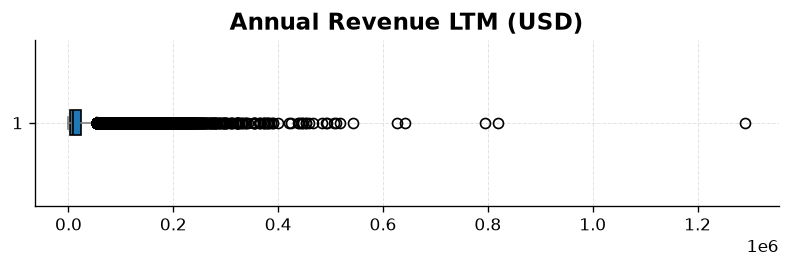

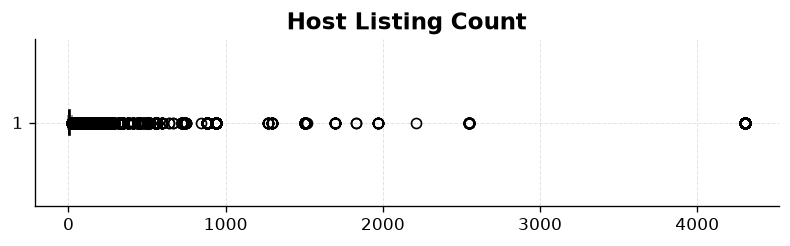

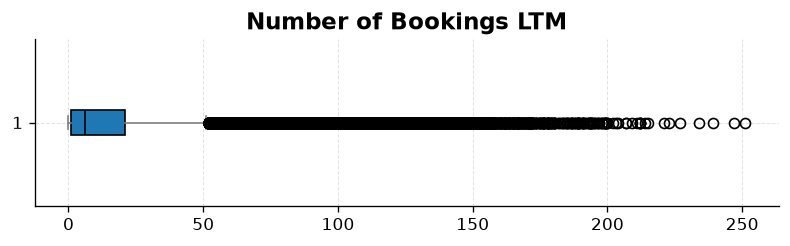

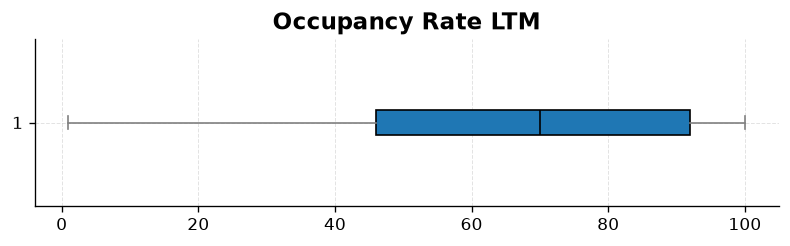

In [31]:
# Boxplots for Outlier Assessment

for column in outlier_variables:

    fig, ax = plt.subplots(figsize=(8, 1.8))

    ax.boxplot(
        airbnb_clean[column].dropna(),
        vert=False,
        patch_artist=True,
        boxprops=dict(facecolor=PROJECT_COLOURS["primary"]),
        medianprops=dict(color="black"),
        whiskerprops=dict(color="grey"),
        capprops=dict(color="grey")
    )

    ax.set_title(f"{column}")

    plt.show()

In [32]:
outlier_summary = []

for column in outlier_variables:

    series = airbnb_clean[column].dropna()

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    count = ((series < lower) | (series > upper)).sum()

    outlier_summary.append({
        "Variable": column,
        "Lower Bound": round(lower, 2),
        "Upper Bound": round(upper, 2),
        "Outliers": count,
        "Percentage (%)": round(count / len(series) * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_summary)

display(outlier_summary)

,Variable,Lower Bound,Upper Bound,Outliers,Percentage (%)
0,Bedrooms,-0.5,3.5,8042,5.51
1,Bathrooms,-0.5,3.5,4238,2.91
2,Max Guests,-1.0,7.0,11713,8.03
3,Cleaning Fee (USD),-97.5,162.5,8256,5.66
4,Extra People Fee (USD),0.0,0.0,27088,18.58
5,Average Daily Rate (USD),-137.5,458.5,9614,6.59
6,Annual Revenue LTM (USD),-27561.0,53711.0,10406,7.14
7,Host Listing Count,-12.5,23.5,13545,15.62
8,Number of Bookings LTM,-29.0,51.0,11942,8.19
9,Occupancy Rate LTM,-23.0,161.0,0,0.00


The Interquartile Range (IQR) method was used to identify potential outliers in key numerical variables. Each variable was subsequently evaluated in the context of the Airbnb marketplace to determine whether the identified observations represented genuine data quality issues or legitimate market variation. Although several variables contained statistical outliers, these observations were considered plausible and were therefore retained. Any transformations required to satisfy modelling assumptions will be considered during the predictive modelling stage.

In [33]:
# Table 9. Outlier Assessment and Treatment Decisions

outlier_treatment = pd.DataFrame({
    "Variable": [
        "Bedrooms",
        "Bathrooms",
        "Max Guests",
        "Cleaning Fee (USD)",
        "Extra People Fee (USD)",
        "Average Daily Rate (USD)",
        "Annual Revenue LTM (USD)",
        "Host Listing Count",
        "Number of Bookings LTM",
        "Occupancy Rate LTM"
    ],
    "Outliers (%)": [
        5.51,
        2.91,
        8.03,
        5.66,
        18.58,
        6.59,
        7.14,
        15.62,
        8.19,
        0.00
    ],
    "Treatment": [
        "Retained",
        "Retained",
        "Retained",
        "Retained",
        "Retained",
        "Retained",
        "Retained",
        "Retained",
        "Retained",
        "No action required"
    ],
    "Justification": [
        "Extreme values represent large properties rather than data errors.",
        "High values are plausible for luxury accommodation.",
        "Large properties can legitimately accommodate many guests.",
        "Variation reflects different pricing strategies across listings.",
        "The IQR method classified all positive fees as outliers because most observations were zero.",
        "Premium listings naturally command higher nightly rates.",
        "High revenue values are expected for successful or luxury listings.",
        "High values likely represent commercial hosts or property management companies.",
        "High booking counts reflect genuine listing performance.",
        "No statistical outliers were identified."
    ]
})

display(outlier_treatment)

save_table_excel(
    dataframe=outlier_treatment,
    filename="table_09_outlier_treatment_decisions.xlsx",
    caption="Table 9. Outlier Assessment and Treatment Decisions",
    sheet_name="Outlier Treatment",
    decimal_places=2
)

,Variable,Outliers (%),Treatment,Justification
0,Bedrooms,5.51,Retained,Extreme values represent large properties rath...
1,Bathrooms,2.91,Retained,High values are plausible for luxury accommoda...
2,Max Guests,8.03,Retained,Large properties can legitimately accommodate ...
3,Cleaning Fee (USD),5.66,Retained,Variation reflects different pricing strategie...
4,Extra People Fee (USD),18.58,Retained,The IQR method classified all positive fees as...
5,Average Daily Rate (USD),6.59,Retained,Premium listings naturally command higher nigh...
6,Annual Revenue LTM (USD),7.14,Retained,High revenue values are expected for successfu...
7,Host Listing Count,15.62,Retained,High values likely represent commercial hosts ...
8,Number of Bookings LTM,8.19,Retained,High booking counts reflect genuine listing pe...
9,Occupancy Rate LTM,0.00,No action required,No statistical outliers were identified.


Table saved to: c:\Users\Probook\NCIRL 2025-2026\DA for Business\CA_DA for Business\tables\table_09_outlier_treatment_decisions.xlsx


#### Final Daaset Validation

In [34]:
remaining_missing = (
    airbnb_clean.isna()
    .sum()
    .to_frame("Missing Values")
)

remaining_missing["Percentage (%)"] = (
    remaining_missing["Missing Values"] / len(airbnb_clean) * 100
).round(2)

remaining_missing = remaining_missing[
    remaining_missing["Missing Values"] > 0
].sort_values("Percentage (%)", ascending=False)

display(remaining_missing)

,Missing Values,Percentage (%)
Cancellation Policy,63517,43.56
Host Listing Count,59101,40.53
Airbnb Cleanliness Rating,21646,14.84
Overall Rating,20851,14.30
Airbnb Checkin Rating,19493,13.37
Airbnb Accuracy Rating,19491,13.37
Airbnb Communication Rating,19490,13.37
Airbnb Value Rating,19494,13.37
Airbnb Location Rating,19492,13.37
Zipcode,15842,10.86


In [35]:
airbnb_clean.dtypes

Listing Title                                                   str
Property Type                                                   str
Listing Type                                                    str
Created Date                                         datetime64[us]
Last Scraped Date                                    datetime64[us]
Country                                                         str
City                                                            str
Zipcode                                                         str
Number of Reviews                                             int64
Bedrooms                                                      int64
Bathrooms                                                     int64
Max Guests                                                    int64
Airbnb Superhost                                                str
Cancellation Policy                                             str
Cleaning Fee (USD)                              

In [36]:
dataset_summary = pd.DataFrame({
    "Metric": [
        "Observations",
        "Variables",
        "Variables Removed",
        "Data Type Conversions",
        "Variables with Remaining Missing Values"
    ],
    "Value": [
        airbnb_clean.shape[0],
        airbnb_clean.shape[1],
        len(columns_to_remove),
        3,
        remaining_missing.shape[0]
    ]
})

display(dataset_summary)

save_table_excel(
    dataframe=dataset_summary,
    filename="table_10_final_dataset_summary.xlsx",
    caption="Table 10. Final Dataset Summary",
    sheet_name="Dataset Summary",
    decimal_places=0
)

,Metric,Value
0,Observations,145825
1,Variables,43
2,Variables Removed,14
3,Data Type Conversions,3
4,Variables with Remaining Missing Values,11


Table saved to: c:\Users\Probook\NCIRL 2025-2026\DA for Business\CA_DA for Business\tables\table_10_final_dataset_summary.xlsx


In [37]:
# Export Cleaned Dataset
# ============================================================

output_path = PROCESSED_DATA_DIR / "airbnb_cleaned.csv"

airbnb_clean.to_csv(output_path, index=False)

print(f"Cleaned dataset saved to:\n{output_path}")

Cleaned dataset saved to:
c:\Users\Probook\NCIRL 2025-2026\DA for Business\CA_DA for Business\data\processed\airbnb_cleaned.csv
